# Statistics for WLASL: Pre-processed

In [12]:
import json
from pathlib import Path
from typing import cast, List, TypedDict, Dict, Tuple
import matplotlib.pyplot as plt
import numpy as np
#locals
from configs import WLASL_ROOT, SPLIT_DIR, CLASSES_PATH
from video_dataset import get_wlasl_info
import stats
import preprocess as preproc
from statistics import median, mean, median_high, median_low
import pandas as pd      # not imported previously, so do it here
from IPython.display import display



## From the WLASL GitHUB page

Data Description
-----------------

* `gloss`: *str*, data file is structured/categorised based on sign gloss, or namely, labels.

* `bbox`: *[int]*, bounding box detected using YOLOv3 of (xmin, ymin, xmax, ymax) convention. Following OpenCV convention, (0, 0) is the up-left corner.

* `fps`: *int*, frame rate (=25) used to decode the video as in the paper.

* `frame_start`: *int*, the starting frame of the gloss in the video (decoding
with FPS=25), *indexed from 1*.

* `frame_end`: *int*, the ending frame of the gloss in the video (decoding with FPS=25). -1 indicates the gloss ends at the last frame of the video.

* `instance_id`: *int*, id of the instance in the same class/gloss.

* `signer_id`: *int*, id of the signer.

* `source`: *str*, a string identifier for the source site.

* `split`: *str*, indicates sample belongs to which subset.

* `url`: *str*, used for video downloading.

* `variation_id`: *int*, id for dialect (indexed from 0).

* `video_id`: *str*, a unique video identifier.


### Additional info:

* The videos come pre-cut from the original youtube videos, therefore, the video_id is essentially a unique identifier for each instance

* There are some issues with the labelling, especially where certain frame start and ends are way too high. However, some of these labels could be corrected by hand to falvage the data. Originally, i just set the start frame to 0 and the end frame to the last frame, however in the modified preprocessing script, i have added a flag to strictly remove these labels for the time being

* All precut video clips have a width and height of 256 pixels. 

* i modified boundign boxes with yolov8


### Naming convention:
For the naming of different functions, 'set' and 'split' can somtimes be used interchangibly to mean different things, which can be confusing. So for all code written by me,
* **SPLIT**: A split of WLASL, one of asl100, asl300, asl1000 and asl2000
* **SET**: A subset of a given wlasl split, one of train, val test


# TODO:
- make a flag to control preprocessed vs unprocessed
- add removed instances
- add bounding box info

## Split

#### Pick split

In [13]:
split_options: List[stats.AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000"]
print('Options:')
for i, split_name in enumerate(split_options):
    print(f'{i} : {split_name}')

Options:
0 : asl100
1 : asl300
2 : asl1000
3 : asl2000


doing this for SAICIST because those experiments kept bad frame range labeled images

In [14]:
# labels_dir = Path('./preprocessed/labels_new')
labels_dir = Path('./preprocessed/labels_old_nobbox') 

with open(CLASSES_PATH, 'r') as f:
    classes = json.load(f)

## Preprocessed

Removed due to limited number of frames (cutoff 9):

Split :  Videos
asl1000 : 18223, 59958
asl2000 : 18223, 59958, 15144

if frame start or frame end were labeled wrong, they were set to 0 or frame length

In [15]:
def get_min_max_num_instances(per_instance_stats: Dict[str, stats.instance_stats]) -> Tuple[int, int]:
    """Returns the minumum and maximum number of instances in a dictionary of instance stats

    Args:
        per_instance_stats (Dict[str, stats.instance_stats]): A dictionary with stats for each class indexed by label_name

    Returns:
        Tuple[int, int]: min, max number of instances.
    """
    mini = float('inf')
    maxi = float(0)
    for inst_stats in per_instance_stats.values():
        num_inst = inst_stats['num_instances']
        if num_inst > maxi:
            maxi = num_inst
        if num_inst < mini:
            mini = num_inst
    return int(mini), int(maxi) 



In [16]:
def get_min_max_num_signers(per_instance_stats: Dict[str, stats.instance_stats]) -> Tuple[int, int]:
    """Returns the minumum and maximum number of signers in a dictionary of instance stats

    Args:
        per_instance_stats (Dict[str, stats.instance_stats]): A dictionary with stats for each class indexed by label_name

    Returns:
        Tuple[int, int]: min, max number of signers.
    """
    mini = float('inf')
    maxi = float(0)
    for inst_stats in per_instance_stats.values():
        num_signers = len(inst_stats['signers_distribution'])
        if num_signers > maxi:
            maxi = num_signers
        if num_signers < mini:
            mini = num_signers
    return int(mini), int(maxi) 

In [17]:
def create_instances_table(per_set_stats: Dict[stats.AVAIL_SETS, stats.set_stats]) -> pd.DataFrame:
    rows = []
    for set_name, set_stats in per_set_stats.items():
        mini_i, maxi_i = get_min_max_num_instances(set_stats['per_instance_stats'])
        mini_s, maxi_s = get_min_max_num_signers(set_stats['per_instance_stats'])
        rows.append({
            'Set name': set_name,
            'Num instances': set_stats['num_instances'],
            'Num signers': set_stats['num_signers'],
            'instances per gloss': f'[{mini_i} - {maxi_i}]',
            'signers per gloss': f'[{mini_s} - {maxi_s}]'
        })

    return pd.DataFrame(rows)
    

In [18]:
all_splits = {split : {} for split in split_options}

for split_name in split_options:
    split_dir = labels_dir / split_name
    set_info = stats.retrieve_split_data(split=split_name, labels_dir=labels_dir, pattern='*_instances*.json')
    seperated = {}
    set_keys = ['train', 'test', 'val']
    print(f'Split info for {split_name}')
    for  key, value in set_info.items():
        preproc_set = cast(List[preproc.InstanceDict], value)
        for set_key in set_keys:
            if key.startswith(set_key):
                seperated[set_key] = preproc_set
                break
    
    sep_wlasl_order = {}
    for key, value in seperated.items():
        sep_wlasl_order[key] = stats.reverse_preproc_format(value, classes=classes)

    
    per_set_stats = {}
    for set_name, glosses_subset in sep_wlasl_order.items():
        per_set_stats[set_name] = stats.get_set_stats(glosses_subset)

    all_splits[split_name] = per_set_stats
    
    display(create_instances_table(per_set_stats))
    print('\n', '-'*10)

Split info for asl100


,Set name,Num instances,Num signers,instances per gloss,signers per gloss
0,val,338,69,[3 - 6],[2 - 6]
1,train,1442,91,[12 - 30],[7 - 15]
2,test,258,56,[2 - 5],[2 - 4]



 ----------
Split info for asl300


,Set name,Num instances,Num signers,instances per gloss,signers per gloss
0,val,901,88,[2 - 6],[2 - 6]
1,train,3549,104,[9 - 30],[5 - 15]
2,test,668,74,[2 - 5],[1 - 4]



 ----------
Split info for asl1000


,Set name,Num instances,Num signers,instances per gloss,signers per gloss
0,val,2319,101,[1 - 6],[1 - 6]
1,train,8977,113,[6 - 30],[4 - 15]
2,test,1876,89,[1 - 5],[1 - 4]



 ----------
Split info for asl2000


,Set name,Num instances,Num signers,instances per gloss,signers per gloss
0,val,3917,109,[1 - 6],[1 - 6]
1,train,14290,117,[1 - 30],[1 - 15]
2,test,2879,105,[1 - 5],[1 - 4]



 ----------


In [19]:

def get_numinstances_distribution(set_statistics: stats.set_stats):
    return stats.HistoGram(
        {gloss : instance['num_instances'] for gloss, instance in set_statistics['per_instance_stats'].items()}
    )
    

In [20]:
split_name: stats.AVAIL_SPLITS = 'asl100'
set_name: stats.AVAIL_SETS = 'test'
per_set_stats = all_splits[split_name]

/home/luke/Code/SLR/code/stats.py:471: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


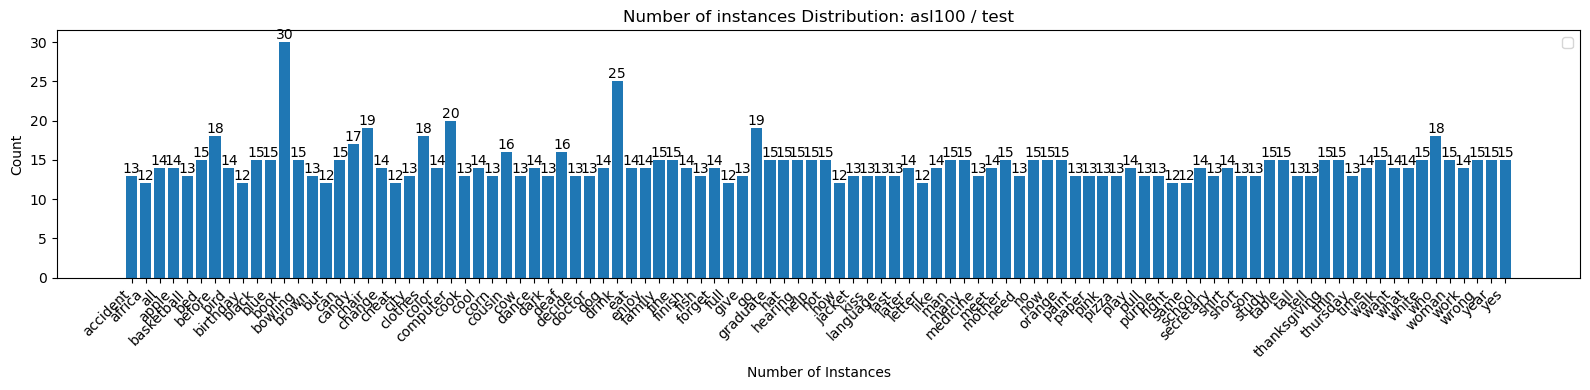

In [26]:
num_inst_dist = get_numinstances_distribution(per_set_stats['train']) #want the trainign distribution

stats.plot_distribution(num_inst_dist, set_name=set_name, split_name=split_name, metric='Number of Instances', categorical=True, figsize=(16, 4))